In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Final_Project"

os.makedirs(f"{BASE_PATH}/models", exist_ok=True)

In [ ]:
!pip install opendatasets

import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/grassknoted/asl-alphabet"

od.download(dataset_url, data_dir="/content/asl_data")

Skipping, found downloaded files in "/content/asl_data/asl-alphabet" (use force=True to force download)


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
full_train_path = "/content/asl_data/asl-alphabet/asl_alphabet_train/asl_alphabet_train"

In [ ]:
import shutil

full_train_path = "/content/asl_data/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
subset_path = "/content/asl_subset"

os.makedirs(subset_path, exist_ok=True)

# remove old broken subset (VERY IMPORTANT)
shutil.rmtree(subset_path, ignore_errors=True)
os.makedirs(subset_path, exist_ok=True)

# get only real class folders (must contain images inside)
all_classes = []

for c in os.listdir(full_train_path):
    class_path = os.path.join(full_train_path, c)

    if os.path.isdir(class_path):
        # check if folder contains images (filter fake folders)
        if len(os.listdir(class_path)) > 0:
            all_classes.append(c)

all_classes = sorted(all_classes)

print("Clean classes found:", all_classes)

N = 10
subset_classes = all_classes[:N]

for c in subset_classes:
    src = os.path.join(full_train_path, c)
    dst = os.path.join(subset_path, c)

    shutil.copytree(src, dst, dirs_exist_ok=True)

print("Final subset created:", subset_classes)

Clean classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Final subset created: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


In [ ]:
print(os.listdir(subset_path))
print("Total subset classes:", len(os.listdir(subset_path)))

['I', 'B', 'C', 'H', 'D', 'J', 'G', 'A', 'E', 'F']
Total subset classes: 10


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(
    subset_path,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 24000 images belonging to 10 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    subset_path,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 6000 images belonging to 10 classes.


In [ ]:
num_classes = train_generator.num_classes

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Final_Project/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6082 - loss: 1.2237
Epoch 1: val_accuracy improved from None to 0.61267, saving model to /content/drive/MyDrive/Final_Project/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Final_Project/best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.7587 - loss: 0.7053 - val_accuracy: 0.6127 - val_loss: 1.5309 - learning_rate: 3.0000e-04
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9254 - loss: 0.2090
Epoch 2: val_accuracy improved from 0.61267 to 0.74267, saving model to /content/drive/MyDrive/Final_Project/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Final_Project/best_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.9359 - loss: 0.1794 - val_accuracy: 0.7427 - val_loss: 0.9764 - learning_rate: 3.0000e-04
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9622 - loss: 0.1101
Epoch 3: val_accur

In [ ]:
cnn_model.save("/content/drive/MyDrive/Final_Project/subset_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
loss, acc = cnn_model.evaluate(validation_generator)
print("Validation Accuracy:", acc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8192 - loss: 1.0192
Validation Accuracy: 0.8191666603088379


In [ ]:
y_pred = np.argmax(cnn_model.predict(validation_generator), axis=1)
y_true = validation_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(validation_generator.class_indices.keys())
))

188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step
              precision    recall  f1-score   support

           A       0.95      0.69      0.80       600
           B       0.75      0.92      0.83       600
           C       0.87      1.00      0.93       600
           D       0.99      0.78      0.88       600
           E       0.54      0.90      0.68       600
           F       1.00      0.94      0.96       600
           G       0.92      0.55      0.69       600
           H       0.69      0.96      0.80       600
           I       1.00      0.47      0.64       600
           J       0.94      0.98      0.96       600

    accuracy                           0.82      6000
   macro avg       0.86      0.82      0.82      6000
weighted avg       0.86      0.82      0.82      6000



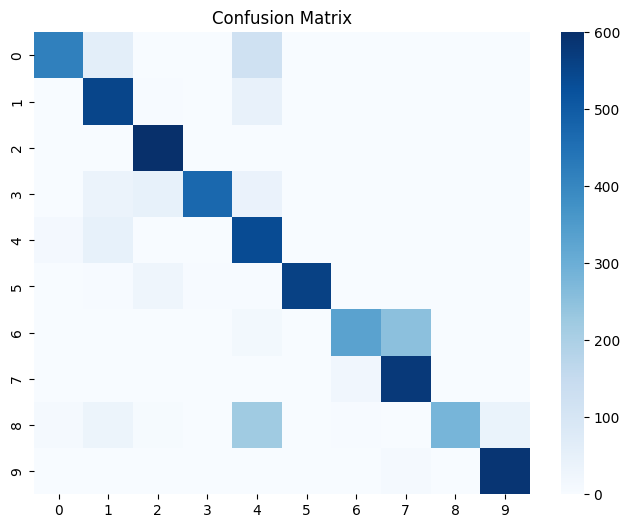

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'asl_data', 'asl_subset', 'drive', 'sample_data']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Final_Project"))

['models', 'best_model.keras', 'subset_model.keras']


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/Final_Project/best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>